# HTTP Server Log Traffic Prediction (Hourly)
## Simple Time Series Forecasting for Short-Term Data

This notebook predicts hourly web traffic using:
- **Hourly patterns** (time of day)
- **Day of week** (weekday vs weekend)
- **Lagged features** (previous hours)

Perfect for 1-month datasets with uniform request types.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import joblib

# Set random seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration

In [2]:
class Config:
    # Data
    DATA_PATH = '/kaggle/input/auto-scaling-analysis-data/train.csv'
    
    # Time series parameters
    CHUNK_TIME = "5min"
    LOOKBACK_HOURS = 120 
    FORECAST_HOURS = 1
    # LAG_FEATURES = [11, 16, 24, 30]  # Important lags in hours
    
    # Model architecture
    HIDDEN_SIZE = 128
    NUM_LAYERS = 2
    DROPOUT = 0.2
    
    # Training
    BATCH_SIZE = 128
    LEARNING_RATE = 1e-3
    EPOCHS = 60
    GRAD_CLIP = 1.0
    WEIGHT_DECAY = 1e-5
    TRAIN_RATIO = 0.8
    
config = Config()

## 1. Data Loading

In [3]:
def load_data(filepath):
    """Load and prepare hourly time series"""
    print("Loading data...")
    df = pd.read_csv(filepath)
    
    # Parse timestamps
    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        format="%d/%b/%Y:%H:%M:%S %z"
    )
    
    # Round to hour
    df_series = df.set_index('timestamp').resample(config.CHUNK_TIME).size().reset_index(name='target')
    
    print(f"\nDataset Info:")
    print(f"  Total time chunk: {len(df_series)}")
    print(f"  Date range: {df_series['timestamp'].min()} to {df_series['timestamp'].max()}")
    print(f"  Total requests: {df_series['target'].sum():,}")
    
    return df_series

In [4]:
series = load_data(config.DATA_PATH)
series.head()

Loading data...

Dataset Info:
  Total time chunk: 15264
  Date range: 1995-07-01 00:00:00-04:00 to 1995-08-22 23:55:00-04:00
  Total requests: 2,934,961


,timestamp,target
0,1995-07-01 00:00:00-04:00,301
1,1995-07-01 00:05:00-04:00,267
2,1995-07-01 00:10:00-04:00,242
3,1995-07-01 00:15:00-04:00,282
4,1995-07-01 00:20:00-04:00,319


/tmp/ipykernel_55/1417997151.py:10: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df_season['target'] = df_season['target'].replace(0, method='ffill').fillna(1)


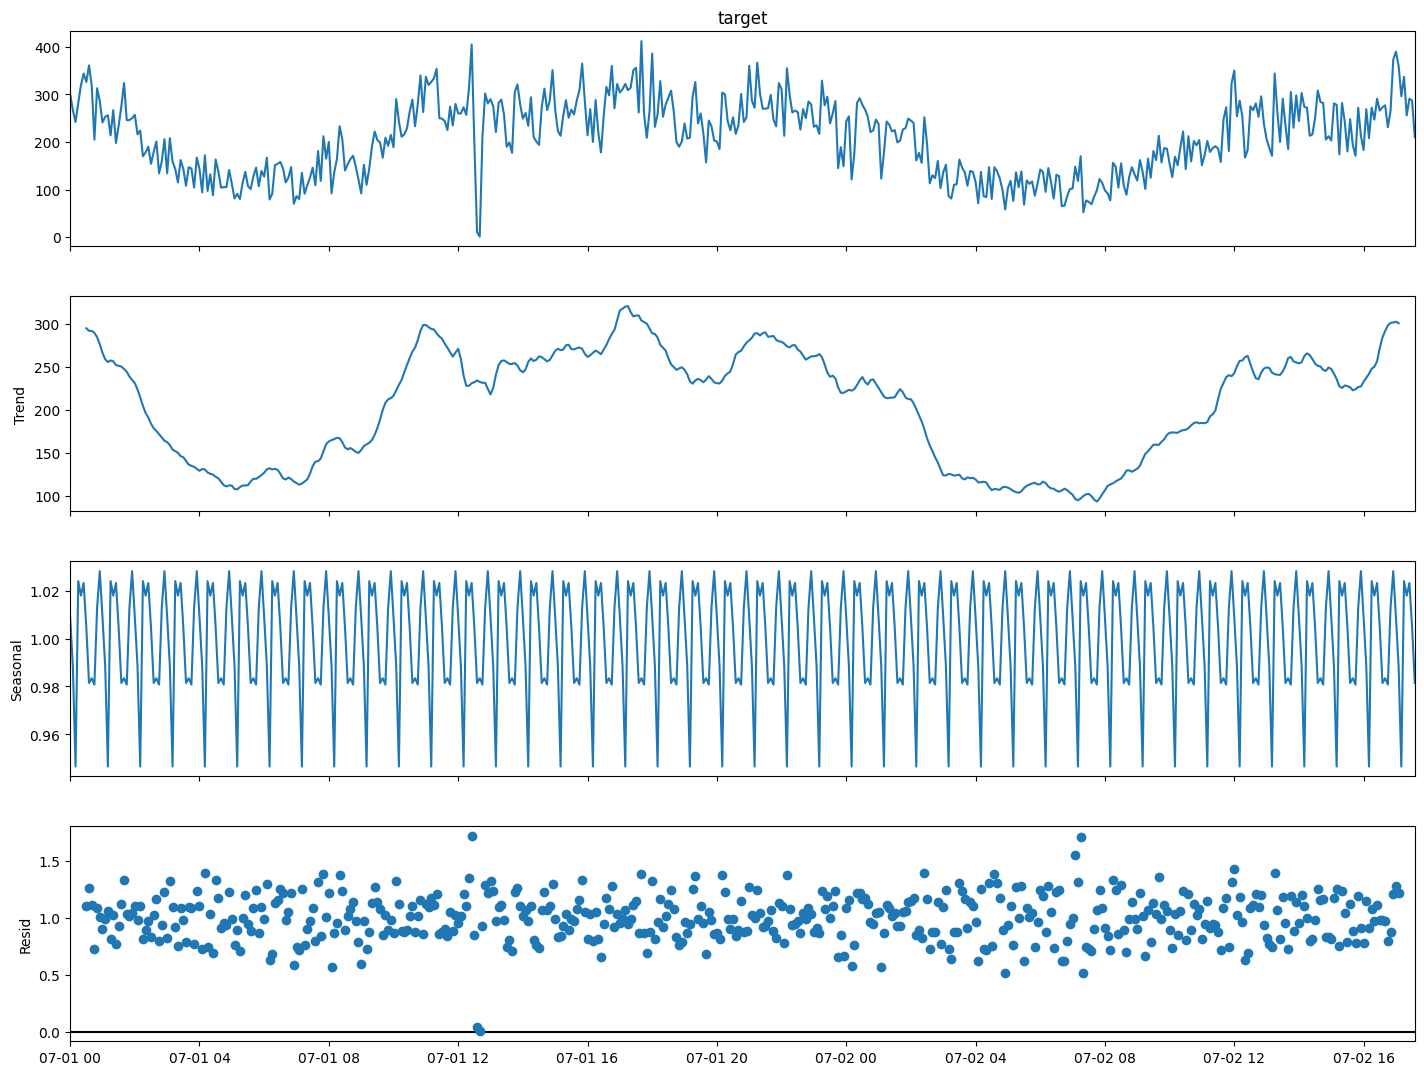

In [40]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Ensure the DataFrame has a DatetimeIndex
df_season = series[:500].copy()
df_season.set_index('timestamp', inplace=True)

# 2. Handle zeros for Multiplicative model
# Multiplicative decomposition fails on 0 or negative values (division by zero)
df_season['target'] = df_season['target'].replace(0, method='ffill').fillna(1)

# 3. Decompose the TARGET column, not the timestamp
# Ensure 'period' is set if your index doesn't have a frequency defined
result = seasonal_decompose(df_season['target'], model='multiplicative', period=12) 

# 4. Plot
fig = result.plot()
fig.set_size_inches(16, 12)
plt.show()

In [64]:
def make_features(data: pd.DataFrame, mode="train", scaler=None):
    # Tạo bản sao để không làm ảnh hưởng đến dữ liệu gốc
    df = data.copy()
    
    # 1. Log transform cho cột mục tiêu
    df['target'] = np.log1p(df['target'])
    if mode == "train":
            scaler = StandardScaler()
            df['target'] = scaler.fit_transform(df[['target']])
            joblib.dump(scaler, "scaler.pkl")
            print("Init new 'scaler.pkl'")
    else:
        if scaler is None:
            try:
                scaler = joblib.load("scaler.pkl")
                print("Loaded scaler.pkl")
            except:
                raise ValueError("Scaler not found!")
        
        # Chỉ transform, không fit lại trên tập test/val
        df['target'] = scaler.transform(df[['target']])
    
    # 2. Trích xuất thông tin thời gian
    # Lưu ý: Đảm bảo data['timestamp'] đã là kiểu datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    hour = df['timestamp'].dt.hour
    dayofweek = df['timestamp'].dt.dayofweek
    
    # 3. Tính toán Sin/Cos để giữ tính liên tục (Cyclical Encoding)
    # 
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)
    df['day_sin'] = np.sin(2 * np.pi * dayofweek / 7.0)
    df['day_cos'] = np.cos(2 * np.pi * dayofweek / 7.0)
    
    # 4. Đánh dấu cuối tuần
    df['is_weekend'] = (dayofweek >= 5).astype(float)
    
    # # 5. Tạo các cột Lag (Trễ) - Dùng shift giúp code nhanh hơn rất nhiều
    # for lag in lags:
    #     df[f'lag_{lag}'] = df['target'].shift(lag)
    
    # 6. Loại bỏ các dòng có giá trị NaN do quá trình tạo lag gây ra
    # Nếu không muốn bỏ, bạn có thể dùng .fillna(0)
    df = df.dropna().reset_index(drop=True)
    
    return df, scaler

In [65]:
df_featured, scaler = make_features(series, mode='train')
df_featured.head(-200)

Init new 'scaler.pkl'


,timestamp,target,hour_sin,hour_cos,day_sin,day_cos,is_weekend
0,1995-07-01 00:00:00-04:00,0.630821,0.000000,1.000000e+00,-0.974928,-0.222521,1.0
1,1995-07-01 00:05:00-04:00,0.559181,0.000000,1.000000e+00,-0.974928,-0.222521,1.0
2,1995-07-01 00:10:00-04:00,0.500446,0.000000,1.000000e+00,-0.974928,-0.222521,1.0
3,1995-07-01 00:15:00-04:00,0.591846,0.000000,1.000000e+00,-0.974928,-0.222521,1.0
4,1995-07-01 00:20:00-04:00,0.665545,0.000000,1.000000e+00,-0.974928,-0.222521,1.0
...,...,...,...,...,...,...,...
15059,1995-08-22 06:55:00-04:00,0.092060,1.000000,6.123234e-17,0.781831,0.623490,0.0
15060,1995-08-22 07:00:00-04:00,0.186605,0.965926,-2.588190e-01,0.781831,0.623490,0.0
15061,1995-08-22 07:05:00-04:00,-0.136683,0.965926,-2.588190e-01,0.781831,0.623490,0.0
15062,1995-08-22 07:10:00-04:00,-0.165947,0.965926,-2.588190e-01,0.781831,0.623490,0.0


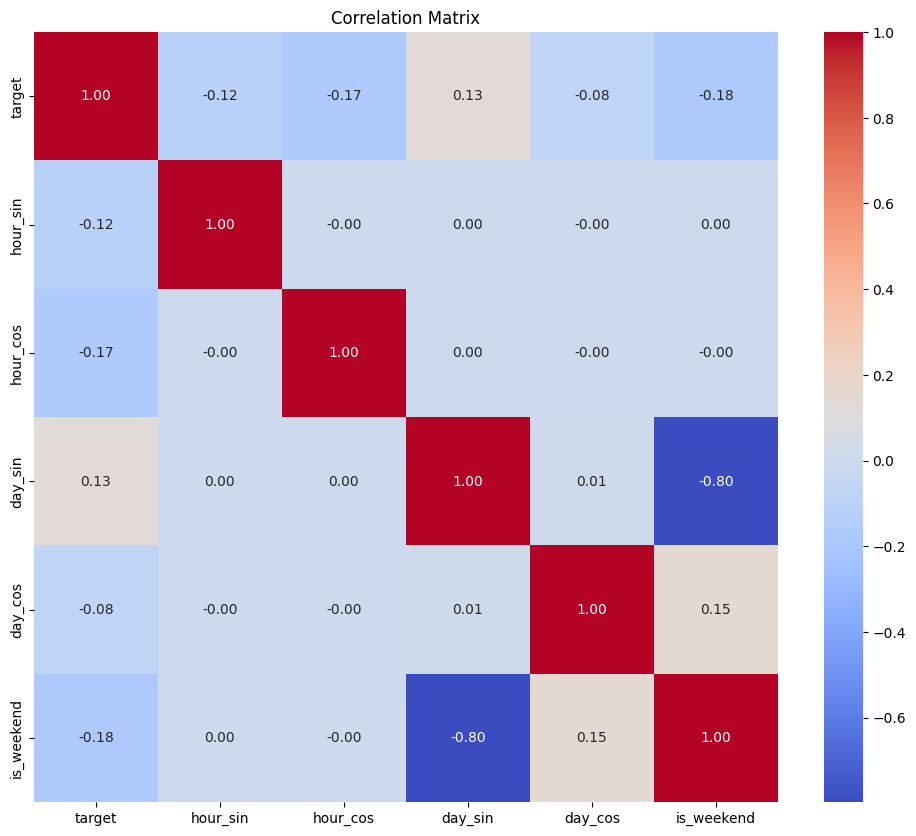

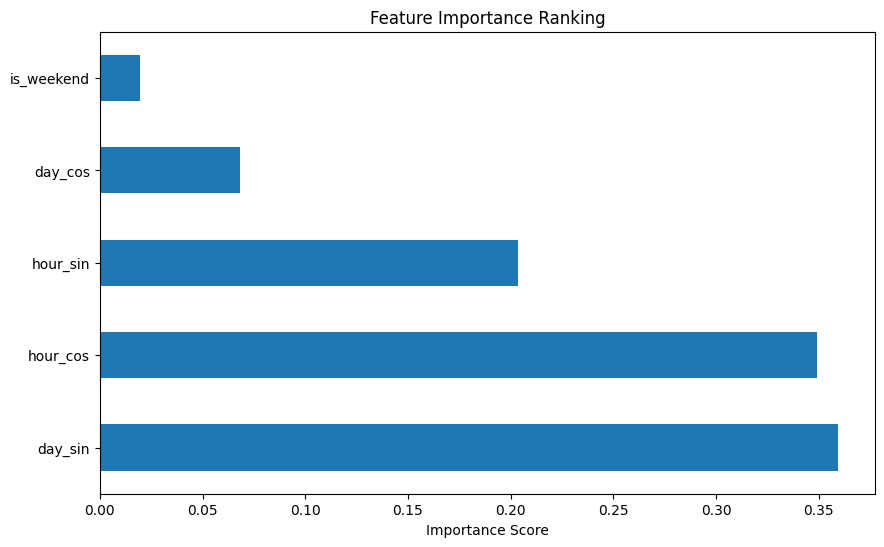

In [66]:
def analyze_features(df, target_col):
    """
    df: DataFrame chứa tất cả các features (bao gồm cả target)
    target_col: Tên cột mục tiêu (ví dụ: 'value')
    """
    # 1. Tính toán Correlation Matrix (Mối quan hệ tuyến tính)
    plt.figure(figsize=(12, 10))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

    # 2. Tính Feature Importance (Mối quan hệ phi tuyến & tác động thực tế)
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Huấn luyện một model nhanh để xem độ quan trọng
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    importances.plot(kind='barh')
    plt.title("Feature Importance Ranking")
    plt.xlabel("Importance Score")
    plt.show()
    
    return importances

# --- Ví dụ áp dụng ---
importances = analyze_features(df_featured.drop(columns=['timestamp'].copy()), target_col='target')

## 2. Dataset Class

In [67]:
class TrafficDataset(Dataset):
    def __init__(self, df, lookback=168, forecast=24):
        self.lookback = lookback
        self.forecast = forecast
        
        # Cột target đã log và scale
        self.target_values = df['target'].values.astype(np.float32)
        
        # Features bao gồm CẢ target và các feature khác (MA, Sin, Cos)
        # Điều này giúp Encoder thấy được giá trị thực của quá khứ
        self.all_features = df.drop(columns=['timestamp']).values.astype(np.float32)

    def __len__(self):
        return len(self.target_values) - self.lookback - self.forecast + 1

    def __getitem__(self, idx):
        # Encoder input: Gồm target quá khứ + features quá khứ
        x_feat = self.all_features[idx : idx + self.lookback]
        
        # Decoder input: Chỉ gồm các feature biết trước (Sin, Cos, is_weekend)
        # Lưu ý: Không được đưa 'target' tương lai vào đây
        # Giả sử cột target là cột số 0 trong all_features, ta sẽ lấy từ cột 1 trở đi
        y_feat = self.all_features[idx + self.lookback : idx + self.lookback + self.forecast, 1:]
        
        y_target = self.target_values[idx + self.lookback : idx + self.lookback + self.forecast]
        
        return {
            'x_features': torch.tensor(x_feat),
            'y_features': torch.tensor(y_feat),
            'y_target': torch.tensor(y_target)
        }

## 3. Model Architecture

In [73]:
class Seq2SeqModel(nn.Module):
    def __init__(self, enc_input_size, dec_input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Encoder: Nhận đầy đủ x_features (bao gồm cả target quá khứ)
        self.encoder = nn.LSTM(
            enc_input_size, 
            hidden_size, 
            num_layers, 
            batch_first=True, 
            dropout=dropout,
            bidirectional=True
        )
        
        self.enc_out_dim = hidden_size * 2
        
        # Decoder: Nhận y_features (không có target) + context vector
        # dec_input_size lúc này sẽ là (enc_input_size - 1)
        self.decoder_lstm = nn.LSTM(
            dec_input_size + self.enc_out_dim, 
            hidden_size, 
            num_layers, 
            batch_first=True, 
            dropout=dropout
        )
        
        self.attention = nn.Sequential(
            nn.Linear(self.enc_out_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        
        self.fc_out = nn.Linear(hidden_size, 1)

    def forward(self, x_features, y_features):
        forecast_len = y_features.shape[1]
        
        # 1. Encoding
        enc_outputs, (hidden, cell) = self.encoder(x_features) 
        
        # 2. Attention
        attn_weights = F.softmax(self.attention(enc_outputs), dim=1)
        context = torch.sum(attn_weights * enc_outputs, dim=1) 
        
        # 3. Decoding
        # Gộp hidden của bidirectional encoder để truyền vào decoder (unidirectional)
        # Lấy num_layers lớp cuối cùng của chiều tiến (forward)
        dec_hidden = (hidden[:self.encoder.num_layers], cell[:self.encoder.num_layers])
        
        context_expanded = context.unsqueeze(1).repeat(1, forecast_len, 1)
        
        # dec_input sẽ có kích thước: dec_input_size + enc_out_dim
        dec_input = torch.cat([y_features, context_expanded], dim=2)
        
        dec_outputs, _ = self.decoder_lstm(dec_input, dec_hidden)
        predictions = self.fc_out(dec_outputs).squeeze(-1)
        
        return predictions

## 4. Loss Functions

In [11]:
class SMAPELoss(nn.Module):
    def __init__(self, epsilon=0.1):
        super(SMAPELoss, self).__init__()
        self.epsilon = epsilon

    def forward(self, pred, target):
        """
        Tính toán Smooth SMAPE để có thể backprop được.
        Công thức gốc: 2 * |y_pred - y_true| / (|y_pred| + |y_true|)
        Công thức smooth: tránh chia cho 0 bằng cách thêm epsilon vào mẫu số.
        """
        target = torch.expm1(target)
        pred = torch.expm1(pred)
        pred = pred.view_as(target)
        
        diff = torch.abs(pred - target)
        # max(sum, 0.5 + epsilon) để chặn dưới
        denominator = torch.abs(pred) + torch.abs(target) + self.epsilon
        smape = 2.0 * diff / denominator
        
        return torch.mean(smape)

In [53]:
def smape_metric(true, pred):
    # true, pred lúc này là mảng numpy đã expm1
    epsilon = 0.1
    summ = np.maximum(np.abs(true) + np.abs(pred) + epsilon, 0.5 + epsilon)
    smape = np.mean((np.abs(pred - true) / summ) * 2.0)
    return smape * 100

## 5. Training Functions

In [69]:
scaler_mean = torch.tensor(scaler.mean_[0]).to(device)
scaler_std = torch.tensor(scaler.scale_[0]).to(device)

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_smape = 0
    
    for batch in dataloader:
        # Lấy dữ liệu từ dictionary của Dataset
        x_features = batch['x_features'].to(device)
        y_features = batch['y_features'].to(device)
        y_target = batch['y_target'].to(device)
        
        # Forward pass
        predictions = model(x_features, y_features)
        
        # Loss
        loss = criterion(predictions, y_target)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient Clipping để tránh bùng nổ gradient
        # if hasattr(config, 'GRAD_CLIP'):
        #     torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in dataloader:
            x_features = batch['x_features'].to(device)
            y_features = batch['y_features'].to(device)
            y_target = batch['y_target'].to(device)
            
            # Forward
            predictions = model(x_features, y_features)
            
            loss = criterion(predictions, y_target)
            total_loss += loss.item()
            
            # Denormalize 
            pred_log = predictions * scaler_std + scaler_mean
            target_log = y_target * scaler_std + scaler_mean
            
            # Chuyển về giá trị gốc (inverse log1p) để tính MAE/SMAPE thực tế
            # .clamp(min=0) để tránh lỗi số âm cực nhỏ do sai số máy tính
            pred_original = torch.expm1(pred_log).clamp(min=0)
            target_original = torch.expm1(target_log).clamp(min=0)
            
            all_preds.append(pred_original.cpu().numpy())
            all_targets.append(target_original.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    # Tính toán metric cuối cùng
    # smape_metric là hàm numpy bạn đã định nghĩa
    val_smape = smape_metric(all_targets, all_preds)
    val_mae = np.mean(np.abs(all_targets - all_preds))
    
    return total_loss / len(dataloader), val_smape, val_mae, all_preds, all_targets

## 6. Main Training

In [74]:
split_idx =int(len(df_featured) * config.TRAIN_RATIO)
train_df = df_featured[:split_idx]
val_df = df_featured[split_idx:]
train_dataset = TrafficDataset(train_df, lookback=config.LOOKBACK_HOURS, forecast=config.FORECAST_HOURS)
val_dataset = TrafficDataset(val_df, lookback=config.LOOKBACK_HOURS, forecast=config.FORECAST_HOURS)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=True)

# 2. Khởi tạo Model với input_size tự động
sample = train_dataset[0]
input_size = sample['x_features'].shape[1]
print(f"Detected Input Features: {input_size}")

Detected Input Features: 6


In [75]:
model = Seq2SeqModel(
    enc_input_size=input_size, 
    dec_input_size=input_size-1,
    hidden_size=config.HIDDEN_SIZE,
    num_layers=config.NUM_LAYERS,
    dropout=config.DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

# criterion = CombinedLoss(smape_weight=1.0, mse_weight=0.1)
criterion = nn.HuberLoss(delta=1.0)
optimizer = AdamW(model.parameters(), lr=config.LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)


Total parameters: 899,970


In [76]:
# Training loop
best_smape = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_smape': [], 'val_mae': []}

best_smape = float('inf')
for epoch in range(50):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_smape, val_mae, _, _ = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_smape'].append(val_smape)
    history['val_mae'].append(val_mae)
    
    if epoch % 5 == 0:
        print(f"Train Loss: {train_loss:.4f}|\tVal SMAPE: {val_smape:.2f}% |\tVal MAE: {val_mae:.2f}")

    # Lưu model tốt nhất dựa trên SMAPE
    if val_smape < best_smape:
        best_smape = val_smape
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"⭐ Saved New Best Model (SMAPE: {val_smape:.2f}%)")

Train Loss: 0.0817 | Val SMAPE: 24.52% | Val MAE: 37.76
⭐ Saved New Best Model (SMAPE: 24.52%)
⭐ Saved New Best Model (SMAPE: 23.06%)
⭐ Saved New Best Model (SMAPE: 22.60%)
⭐ Saved New Best Model (SMAPE: 22.29%)
⭐ Saved New Best Model (SMAPE: 22.17%)
Train Loss: 0.0183 | Val SMAPE: 21.98% | Val MAE: 32.97
⭐ Saved New Best Model (SMAPE: 21.98%)
⭐ Saved New Best Model (SMAPE: 21.97%)
Train Loss: 0.0180 | Val SMAPE: 22.20% | Val MAE: 32.84
⭐ Saved New Best Model (SMAPE: 21.78%)
⭐ Saved New Best Model (SMAPE: 21.74%)
Train Loss: 0.0174 | Val SMAPE: 21.78% | Val MAE: 32.54
Train Loss: 0.0168 | Val SMAPE: 21.72% | Val MAE: 32.92
⭐ Saved New Best Model (SMAPE: 21.72%)
⭐ Saved New Best Model (SMAPE: 21.60%)
Train Loss: 0.0167 | Val SMAPE: 21.83% | Val MAE: 32.77
Train Loss: 0.0162 | Val SMAPE: 21.69% | Val MAE: 32.60
Train Loss: 0.0161 | Val SMAPE: 21.69% | Val MAE: 32.65
⭐ Saved New Best Model (SMAPE: 21.56%)
Train Loss: 0.0156 | Val SMAPE: 21.67% | Val MAE: 32.54
Train Loss: 0.0156 | Val SMA

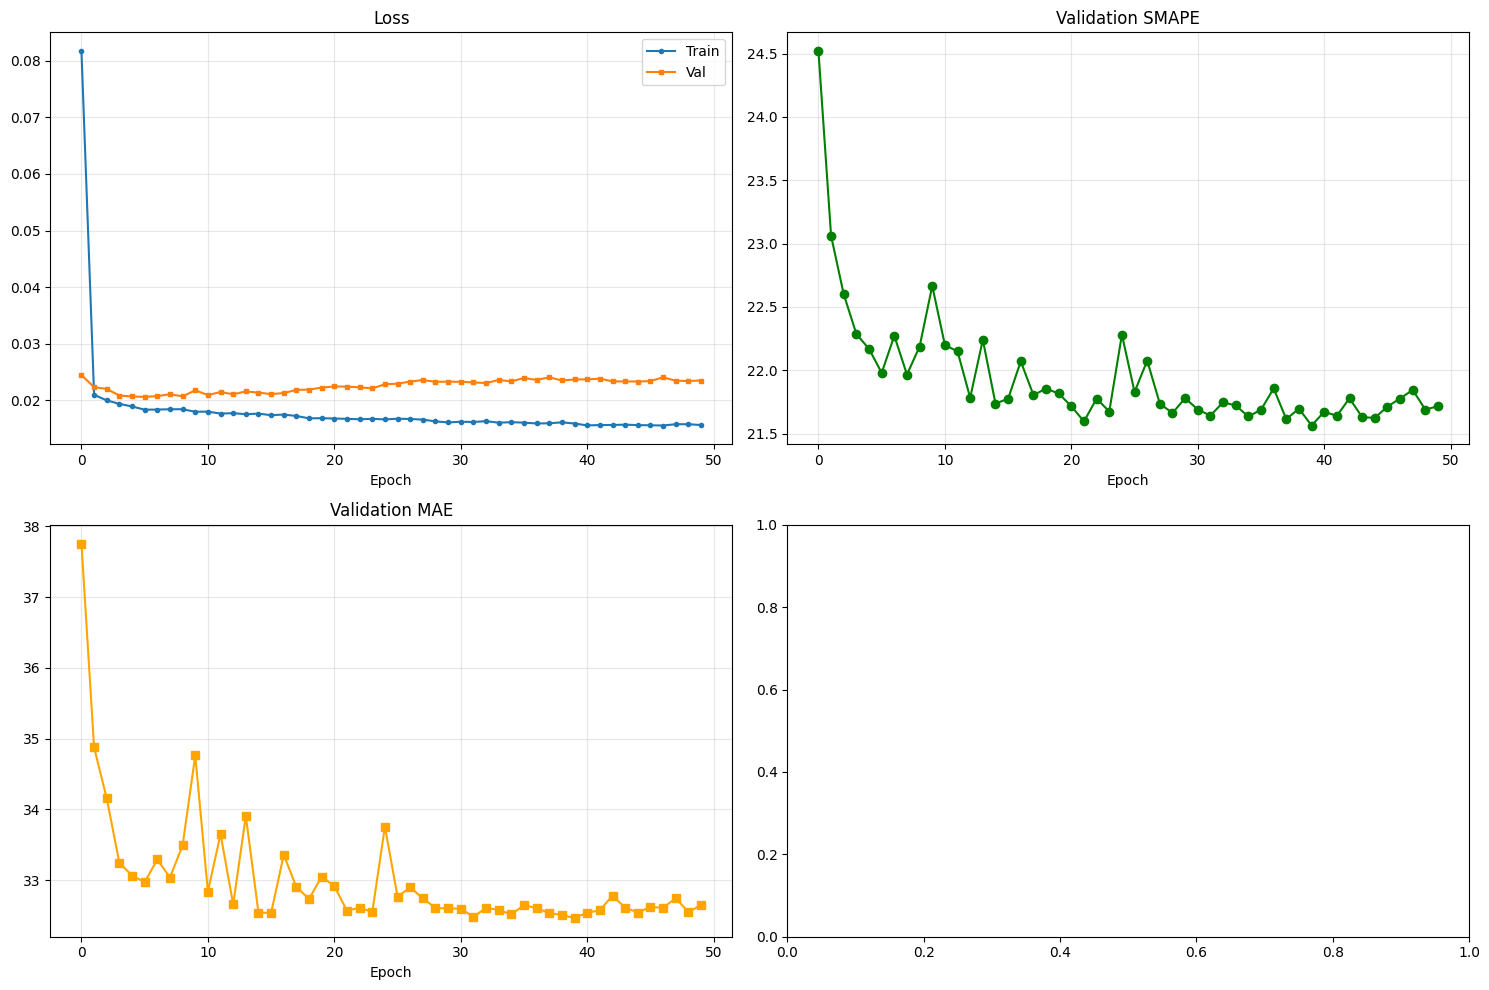

In [77]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history['train_loss'], label='Train', marker='o', markersize=3)
axes[0, 0].plot(history['val_loss'], label='Val', marker='s', markersize=3)
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history['val_smape'], marker='o', color='green')
axes[0, 1].set_title('Validation SMAPE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(history['val_mae'], marker='s', color='orange')
axes[1, 0].set_title('Validation MAE')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluation & Visualization

In [98]:
TEST_FILE = "/kaggle/input/auto-scaling-analysis-data/test.csv"
test_series = load_data(TEST_FILE)
test_series.head()

Loading data...

Dataset Info:
  Total time chunk: 2592
  Date range: 1995-08-23 00:00:00-04:00 to 1995-08-31 23:55:00-04:00
  Total requests: 526,651


,timestamp,target
0,1995-08-23 00:00:00-04:00,210
1,1995-08-23 00:05:00-04:00,125
2,1995-08-23 00:10:00-04:00,108
3,1995-08-23 00:15:00-04:00,173
4,1995-08-23 00:20:00-04:00,130


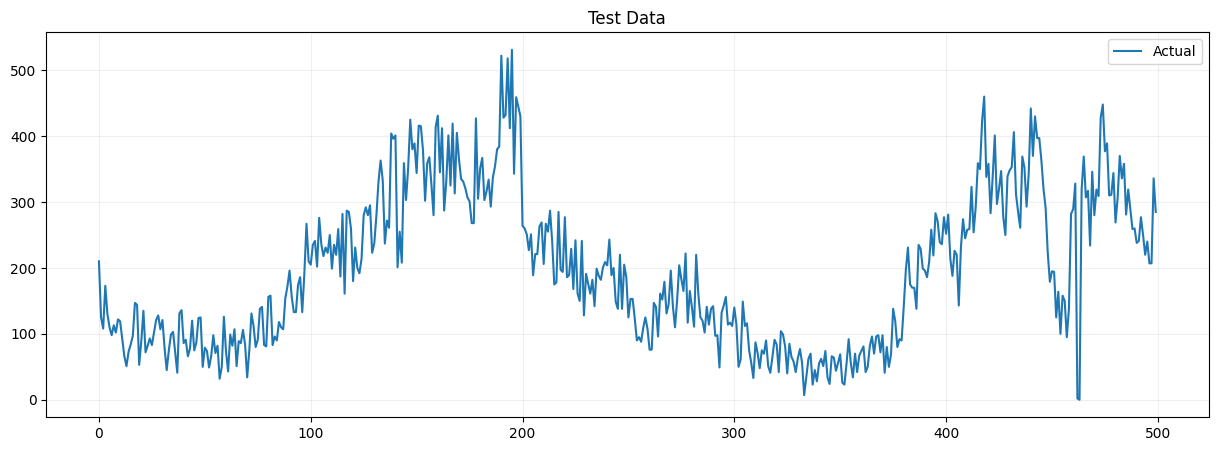

In [99]:
plt.figure(figsize=(15, 5))
plt.plot(test_series['target'][:500], label='Actual', color='#1f77b4')
plt.title("Test Data")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [100]:
padding_data = series.tail(config.LOOKBACK_HOURS)
full_test_series = pd.concat([padding_data, test_series], axis=0).reset_index(drop=True)

df_test_featured, _ = make_features(
    test_series, 
    # lags=config.LAG_FEATURES, 
    mode='test', 
    scaler=scaler
)

test_dataset = TrafficDataset(
    df_test_featured, 
    lookback=config.LOOKBACK_HOURS, 
    forecast=config.FORECAST_HOURS
)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [108]:
# Lấy tham số scaler để giải mã trực tiếp bằng Tensor
s_mean = torch.tensor(scaler.mean_[0]).to(device)
s_std = torch.tensor(scaler.scale_[0]).to(device)

all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        x_features = batch['x_features'].to(device)
        y_features = batch['y_features'].to(device)
        y_target = batch['y_target'].to(device)
        
        # Forward pass (Kết quả đang ở dạng Log + Scaled)
        outputs = model(x_features, y_features)
        
        # Bước 1: Nghịch đảo chuẩn hóa (Inverse Scaling)
        # Formula: x_log = x_scaled * std + mean
        pred_log = outputs * s_std + s_mean
        target_log = y_target * s_std + s_mean
        
        # Bước 2: Nghịch đảo Log (Inverse Log1p)
        # Formula: x_original = exp(x_log) - 1
        pred_final = torch.expm1(pred_log).clamp(min=0)
        target_final = torch.expm1(target_log).clamp(min=0)
        
        all_preds.append(pred_final.cpu().numpy())
        all_targets.append(target_final.cpu().numpy())

# Gộp kết quả
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

Testing:   0%|          | 0/20 [00:00<?, ?it/s]

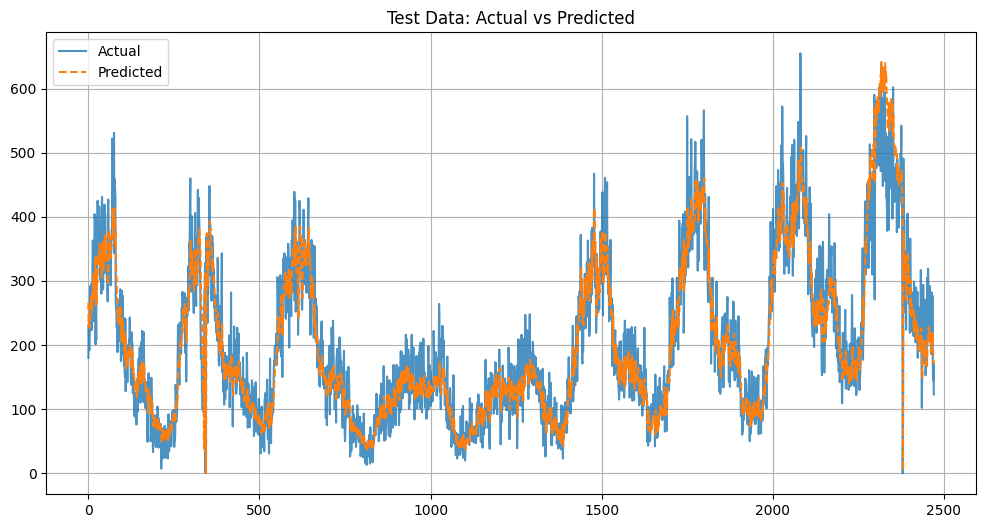

In [109]:
plt.figure(figsize=(12, 6))
plt.plot(all_targets.flatten()[:], label='Actual', color='#1f77b4', alpha=0.8)
plt.plot(all_preds.flatten()[:], label='Predicted', color='#ff7f0e', linestyle='--')
plt.title("Test Data: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [103]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
actuals_inv = all_targets.flatten()
predictions_inv = all_preds.flatten()
mse = mean_squared_error(actuals_inv, predictions_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals_inv, predictions_inv)

# MAPE (Mean Absolute Percentage Error)
# Cho biết model sai lệch bao nhiêu % so với thực tế.
def calculate_mape(y_true, y_pred):
    # MAPE
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # SMAPE
    epsilon = 0.1
    summ = np.maximum(np.abs(y_true) + np.abs(y_pred) + epsilon, 0.5 + epsilon)
    smape = np.mean((np.abs(y_pred - y_true) / summ) * 2.0) * 100
    return mape, smape

mape, smape = calculate_mape(actuals_inv, predictions_inv)

# R2 Score (Coefficient of Determination)
# Đo độ phù hợp của mô hình (càng gần 1 càng tốt, âm là model tệ hơn đoán bừa)
r2 = r2_score(actuals_inv, predictions_inv)

print("-" * 30)
print(f"Evaluation Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")
print(f"R2   : {r2:.4f}")
print("-" * 30)

------------------------------
Evaluation Metrics:
MSE  : 2278.3083
RMSE : 47.7316
MAE  : 34.9662
MAPE : 28.25%
SMAPE: 20.23%
R2   : 0.8512
------------------------------


In [104]:
from scipy.signal import find_peaks

class EventEvaluator:
    def __init__(self, tolerance=1):
        """
        tolerance: Số bước thời gian cho phép sai lệch.
                   Ví dụ tolerance=2 nghĩa là đỉnh dự đoán lệch sớm/muộn 2 nhịp 
                   so với đỉnh thật vẫn được tính là đúng (True Positive).
        """
        self.tolerance = tolerance

    def _match_events(self, true_indices, pred_indices):
        """
        Hàm cốt lõi để ghép cặp sự kiện giữa thực tế và dự đoán 
        dựa trên khoảng cách thời gian gần nhất.
        """
        tp = 0  # True Positives
        matched_pred = set()
        matched_true = set()
        
        # Tạo danh sách các cặp ứng viên có thể match (khoảng cách <= tolerance)
        candidates = []
        for t_idx in true_indices:
            for p_idx in pred_indices:
                dist = abs(t_idx - p_idx)
                if dist <= self.tolerance:
                    candidates.append((dist, t_idx, p_idx))
        
        # Sắp xếp ưu tiên các cặp gần nhau nhất trước
        candidates.sort(key=lambda x: x[0])
        
        # Duyệt và ghép cặp (Greedy matching)
        for _, t_idx, p_idx in candidates:
            if t_idx not in matched_true and p_idx not in matched_pred:
                matched_true.add(t_idx)
                matched_pred.add(p_idx)
                tp += 1
                
        fn = len(true_indices) - len(matched_true) # Có thật mà không đoán được
        fp = len(pred_indices) - len(matched_pred) # Đoán mà không có thật
        
        return tp, fp, fn

    def _calculate_metrics(self, tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        return {
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "TP": tp, "FP": fp, "FN": fn
        }

    def evaluate_spikes(self, y_true, y_pred, threshold_std=3):
        """
        Đánh giá Spikes (các điểm đột biến vượt quá giới hạn Z-score).
        Spike được định nghĩa là giá trị > mean + k*std
        """
        # Tính ngưỡng dựa trên dữ liệu thật
        mean = np.mean(y_true)
        std = np.std(y_true)
        limit = mean + threshold_std * std
        
        true_spikes = np.where(y_true > limit)[0]
        pred_spikes = np.where(y_pred > limit)[0]
        
        tp, fp, fn = self._match_events(true_spikes, pred_spikes)
        return self._calculate_metrics(tp, fp, fn)

In [112]:
all_targets

array([[179.99997],
       [230.99998],
       [199.99995],
       ...,
       [145.00003],
       [173.99997],
       [122.99999]], dtype=float32)

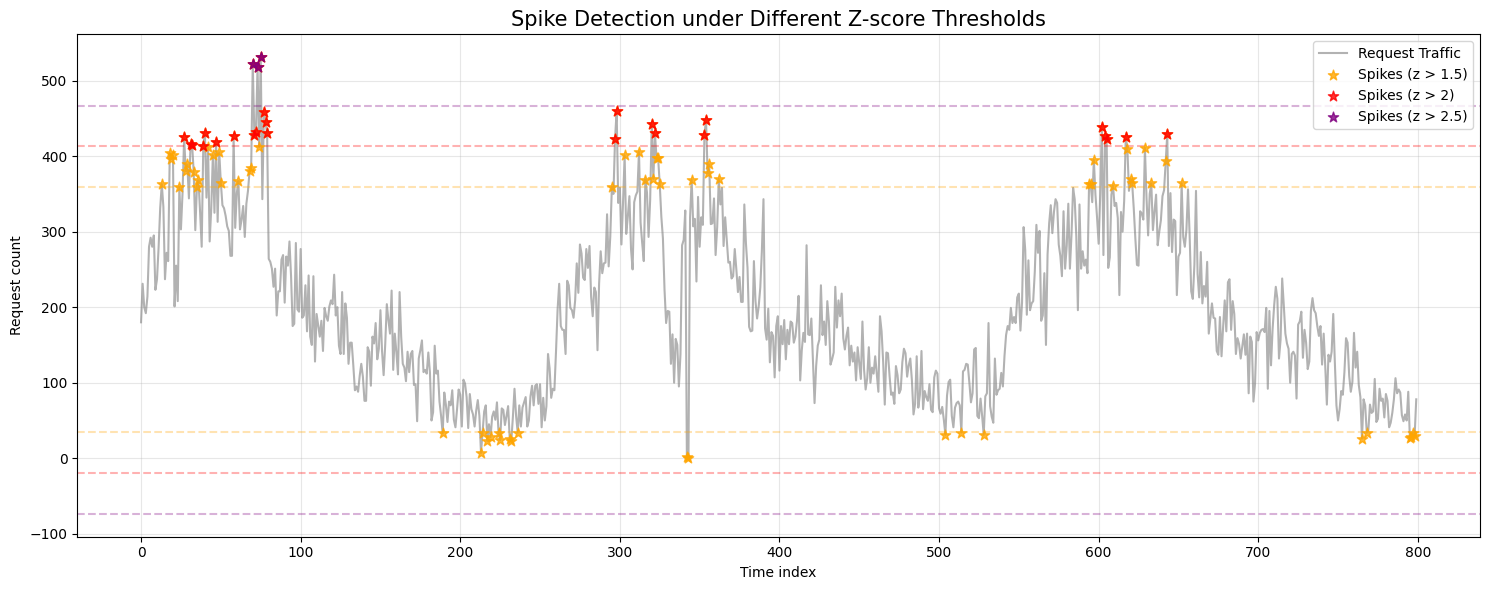

In [113]:
y = all_targets[:800, 0]
x = np.arange(len(y))

mean = np.mean(y)
std = np.std(y)

thresholds = [1.5, 2, 2.5]
colors = ['orange', 'red', 'purple']

plt.figure(figsize=(15, 6))
plt.plot(x, y, label='Request Traffic', color='gray', alpha=0.6)

for thres, color in zip(thresholds, colors):
    spikes = np.where(np.abs(y - mean) > thres * std)[0]

    plt.scatter(
        x[spikes],
        y[spikes],
        s=60,
        marker='*',
        color=color,
        alpha=0.8,
        label=f'Spikes (z > {thres})',
        zorder=4
    )

    # Vẽ ngưỡng
    plt.axhline(mean + thres * std, color=color, linestyle='--', alpha=0.3)
    plt.axhline(mean - thres * std, color=color, linestyle='--', alpha=0.3)

plt.title("Spike Detection under Different Z-score Thresholds", fontsize=15)
plt.xlabel("Time index")
plt.ylabel("Request count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [114]:
from pprint import pprint

evaluator = EventEvaluator(tolerance=2)

spike_results = {}

for thres in thresholds:
    metrics = evaluator.evaluate_spikes(
        actuals_inv.flatten(),
        predictions_inv.flatten(),
        threshold_std=thres
    )
    spike_results[f"z>{thres}"] = metrics

print("\n--- SPIKE DETECTION BY Z-SCORE ---")
pprint(spike_results)


--- SPIKE DETECTION BY Z-SCORE ---
{'z>1.5': {'F1-Score': 0.7865168539325843,
           'FN': 73,
           'FP': 22,
           'Precision': 0.8883248730964467,
           'Recall': 0.7056451612903226,
           'TP': 175},
 'z>2': {'F1-Score': 0.6697247706422017,
         'FN': 38,
         'FP': 34,
         'Precision': 0.6822429906542056,
         'Recall': 0.6576576576576577,
         'TP': 73},
 'z>2.5': {'F1-Score': 0.48979591836734687,
           'FN': 19,
           'FP': 31,
           'Precision': 0.43636363636363634,
           'Recall': 0.5581395348837209,
           'TP': 24}}


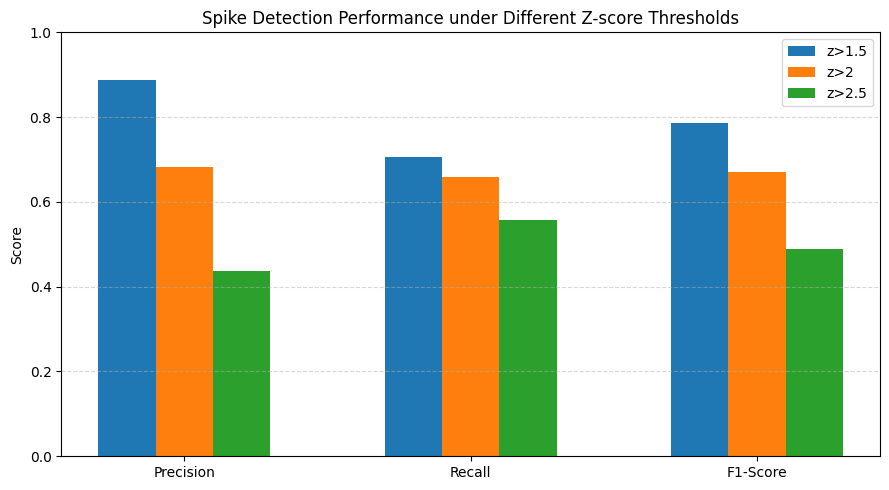

In [115]:
metric_names = ["Precision", "Recall", "F1-Score"]

x = np.arange(len(metric_names))
width = 0.2

plt.figure(figsize=(9,5))

for i, (label, vals) in enumerate(spike_results.items()):
    scores = [vals[m] for m in metric_names]
    plt.bar(x + i * width, scores, width, label=label)

plt.xticks(x + width, metric_names)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Spike Detection Performance under Different Z-score Thresholds")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()